In [209]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config Inline.Backend.figure_format = 'svg'

In [210]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value: (data = {self.data})"
    def __add__(self,other):

        other = other if isinstance(other,Value) else Value(other, label='constant')
        out = Value(self.data + other.data, (self,other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        
        return out

    def __radd__(self,other):
        return self + other;

    def __mul__(self,other):

        other = other if isinstance(other,Value) else Value(other, label='constant')
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        
        return out

    def __pow__(self,other):
        assert isinstance(other,(int,float)), "only supporting int/float for now"
        out = Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad

        out._backward = _backward

        return out
        
    def __rmul__(self,other):
        return self * other;

    def __truediv__(self,other):
        return self * (other**-1)

    def __neg__(self):
        return self * -1

    def __sub__(self,other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1-(t**2)) * out.grad

        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out
        
    def backward(self):

        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()
    

In [211]:
a = Value(2.0)
b = Value(4.0)
a-b

Value: (data = -2.0)

In [212]:
from graphviz import Digraph

def trace(root):

    nodes,edges = set(),set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)

    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr = {'rankdir' : 'LR'})

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape='record')

        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [213]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432,label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'


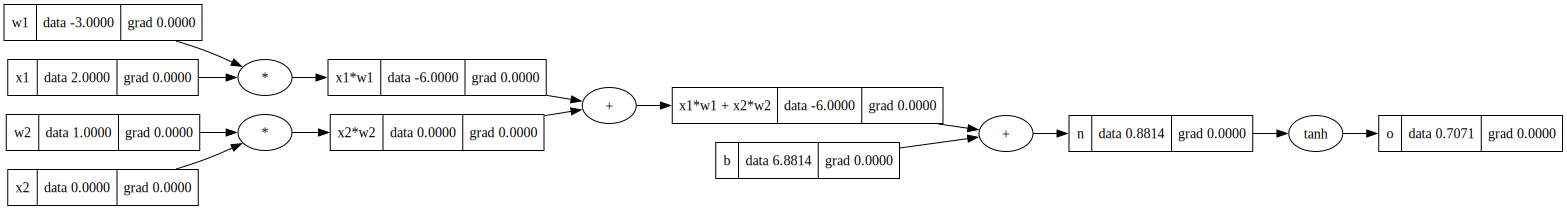

In [214]:
draw_dot(o)

In [215]:
o.backward()

In [216]:
o + 2

Value: (data = 2.7071067811865475)

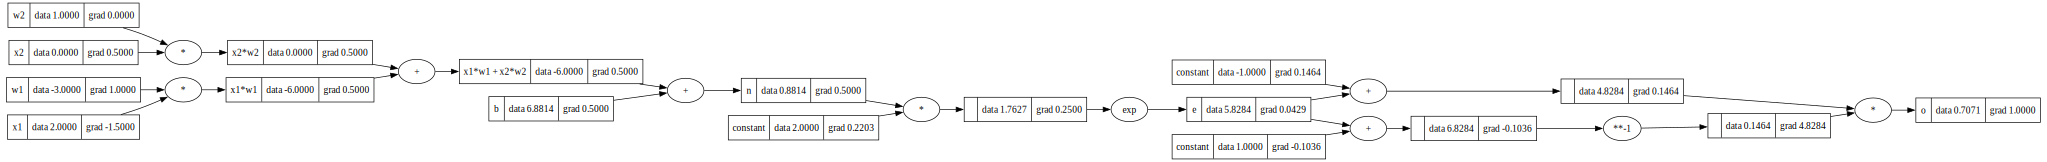

In [217]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432,label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'
# f = 2*n; f.label='f'
e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1); o.label='o'

o.backward()
draw_dot(o)


In [218]:
import torch
import random

In [219]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params
        return[p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):

        return [p for layer in self.layers for p in layer.parameters()]



In [265]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])

In [266]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0]


In [250]:
loss = sum([(yout-ygt)**2 for ygt,yout in zip(ys,ypred)])
loss

Value: (data = 0.0017936949280830952)

In [223]:
loss.backward()

In [224]:
n.layers[0].neurons[0].w[0].grad

-0.9702968840202003

In [ ]:
draw_dot(loss)

In [240]:
loss.backward()
for p in n.parameters():
    p.data += -0.01 * p.grad

In [241]:
ypred = [n(x) for x in xs]
loss = sum([(yout-ygt)**2 for ygt,yout in zip(ys,ypred)])
loss

Value: (data = 0.045906309195367895)

In [267]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt,yout in zip(ys,ypred)])

    for p in n.parameters():
        p.grad = 0.0
    
    loss.backward()
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)

0 2.645475768213551
1 1.430562252825398
2 0.8863021724349521
3 0.621702576557133
4 0.458534166181099
5 0.3495395432655788
6 0.2751929253363633
7 0.22309208616369652
8 0.18543625534755215
9 0.1573929971025358
10 0.13593340505206492
11 0.11911432942810105
12 0.10565496926059628
13 0.09468779146990039
14 0.08560981760758123
15 0.07799185677694426
16 0.07152173505419113
17 0.06596790534730221
18 0.06115556417953025
19 0.056950625400494975


In [268]:
ypred

[Value: (data = 0.8890127407336076),
 Value: (data = -0.9193799492281306),
 Value: (data = -0.8534893054482087),
 Value: (data = 0.8708974149115423)]